In [1]:
# %% Cell 1: Imports and setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Robust project-root detection ---
def _find_project_root(start: str) -> str:
    current = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(current, "src")):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            raise RuntimeError(f"Could not find project root above {start}")
        current = parent

try:
    _HERE = os.path.dirname(os.path.abspath(__file__))   # type: ignore[name-defined]
except NameError:
    _HERE = os.getcwd()
_HERE = str(_HERE)

PROJECT_ROOT = _find_project_root(_HERE)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

RUNS_DIR = os.path.join(PROJECT_ROOT, "runs")
FIG_DIR = os.path.join(_HERE, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

EXPERIMENTS = ["default", "exp1_subarray", "exp2_beam_selection"]

COLORS = {
    "default": "#1f77b4",
    "exp1_subarray": "#d62728",
    "exp2_beam_selection": "#2ca02c",
}
LABELS = {
    "default": "Default (4 users, 60 deg)",
    "exp1_subarray": "Exp1 (3 users, 75 deg, sparse)",
    "exp2_beam_selection": "Exp2 (4 users, 10 deg, tight)",
}

SMOOTH_WIN = 20

print("Imports OK")
print(f"Project root:  {PROJECT_ROOT}")
print(f"Runs dir:      {RUNS_DIR}")
print(f"Figures saved: {FIG_DIR}")

Imports OK
Project root:  c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys
Runs dir:      c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\runs
Figures saved: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\notebooks\figures


In [2]:
# %% Cell 2: Load experiment CSVs
dfs = {}
for name in EXPERIMENTS:
    csv_path = os.path.join(RUNS_DIR, name, "metrics.csv")
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing: {csv_path}")
    df = pd.read_csv(csv_path)
    dfs[name] = df
    print(f"[{name:22s}] {len(df):4d} episodes loaded")

cols = set(dfs["default"].columns)
for name, df in dfs.items():
    assert set(df.columns) == cols, f"{name} has different columns"
print(f"\nColumns: {sorted(cols)}")

[default               ]  500 episodes loaded
[exp1_subarray         ]  300 episodes loaded
[exp2_beam_selection   ]  400 episodes loaded

Columns: ['avg_reward', 'episode', 'epsilon', 'high_level_loss', 'interference_power', 'low_level_loss', 'num_active_beams', 'num_active_subarrays', 'steps', 'sum_rate', 'total_reward', 'wall_time_s']


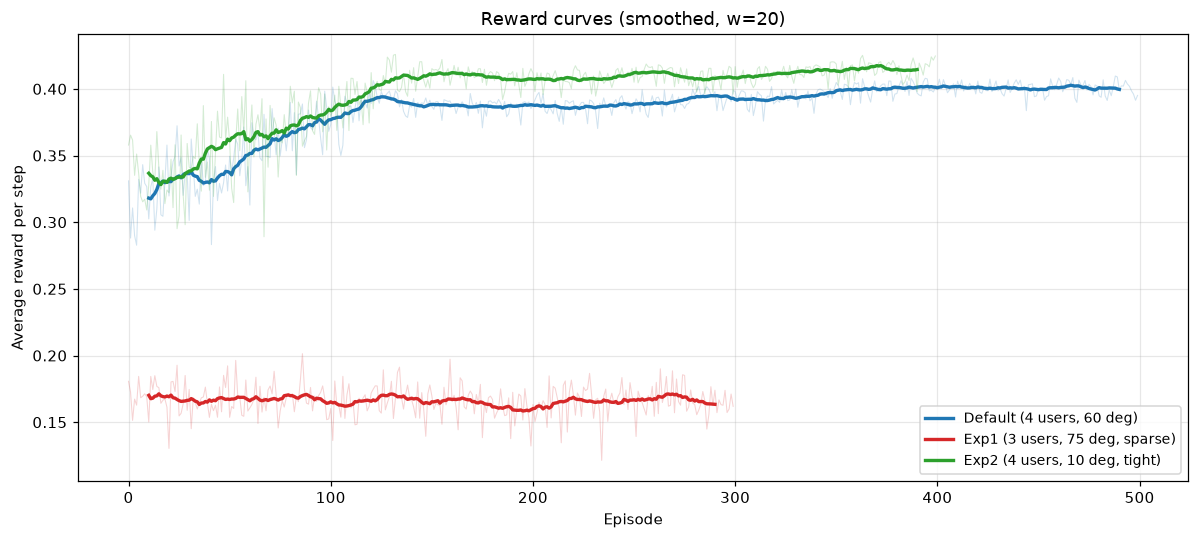

<Figure size 704x528 with 0 Axes>

In [3]:
# %% Cell 3: FIGURE 1 - Reward curves
fig, ax = plt.subplots(figsize=(11, 5))

def smooth(x, w=SMOOTH_WIN):
    if len(x) < w:
        return x, np.arange(len(x))
    kernel = np.ones(w) / w
    s = np.convolve(x, kernel, mode="valid")
    idx = np.arange(w // 2, w // 2 + len(s))
    return s, idx

for name in EXPERIMENTS:
    df = dfs[name]
    eps = df["episode"].values
    reward = df["avg_reward"].values
    ax.plot(eps, reward, color=COLORS[name], alpha=0.2, linewidth=0.7)
    s, idx = smooth(reward)
    ax.plot(eps[idx], s, color=COLORS[name], linewidth=2.2,
            label=LABELS[name])

ax.set_xlabel("Episode")
ax.set_ylabel("Average reward per step")
ax.set_title(f"Reward curves (smoothed, w={SMOOTH_WIN})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_01_reward_curves.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)   

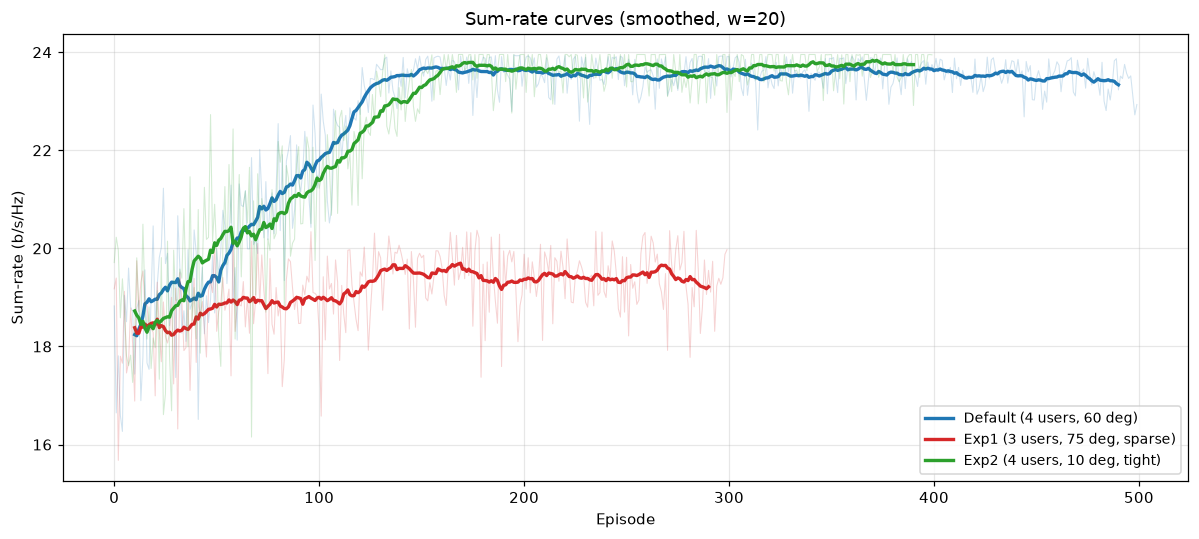

<Figure size 704x528 with 0 Axes>

In [4]:
# %% Cell 4: FIGURE 2 - Sum-rate curves
fig, ax = plt.subplots(figsize=(11, 5))

for name in EXPERIMENTS:
    df = dfs[name]
    eps = df["episode"].values
    rate = df["sum_rate"].values
    ax.plot(eps, rate, color=COLORS[name], alpha=0.2, linewidth=0.7)
    s, idx = smooth(rate)
    ax.plot(eps[idx], s, color=COLORS[name], linewidth=2.2,
            label=LABELS[name])

ax.set_xlabel("Episode")
ax.set_ylabel("Sum-rate (b/s/Hz)")
ax.set_title(f"Sum-rate curves (smoothed, w={SMOOTH_WIN})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_02_rate_curves.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)   

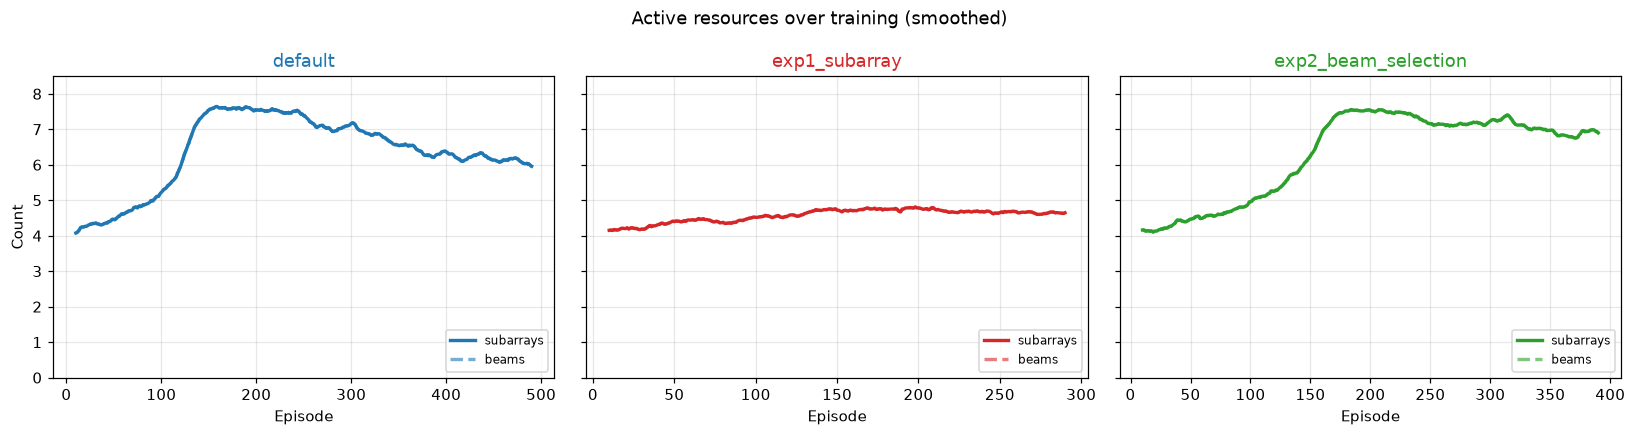

<Figure size 704x528 with 0 Axes>

In [5]:
# %% Cell 5: FIGURE 3 - Active resources (subplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, EXPERIMENTS):
    df = dfs[name]
    eps = df["episode"].values
    subs = df["num_active_subarrays"].values
    beams = df["num_active_beams"].values
    subs_s, idx = smooth(subs)
    beams_s, _ = smooth(beams)
    ax.plot(eps[idx], subs_s, color=COLORS[name], linewidth=2.2,
            label="subarrays")
    ax.plot(eps[idx], beams_s, color=COLORS[name], linewidth=2.2,
            linestyle="--", alpha=0.6, label="beams")
    ax.set_xlabel("Episode")
    ax.set_title(name, color=COLORS[name])
    ax.legend(loc="lower right", fontsize=8)
    ax.set_ylim(0, 8.5)

axes[0].set_ylabel("Count")
plt.suptitle("Active resources over training (smoothed)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_03_actions.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig) 

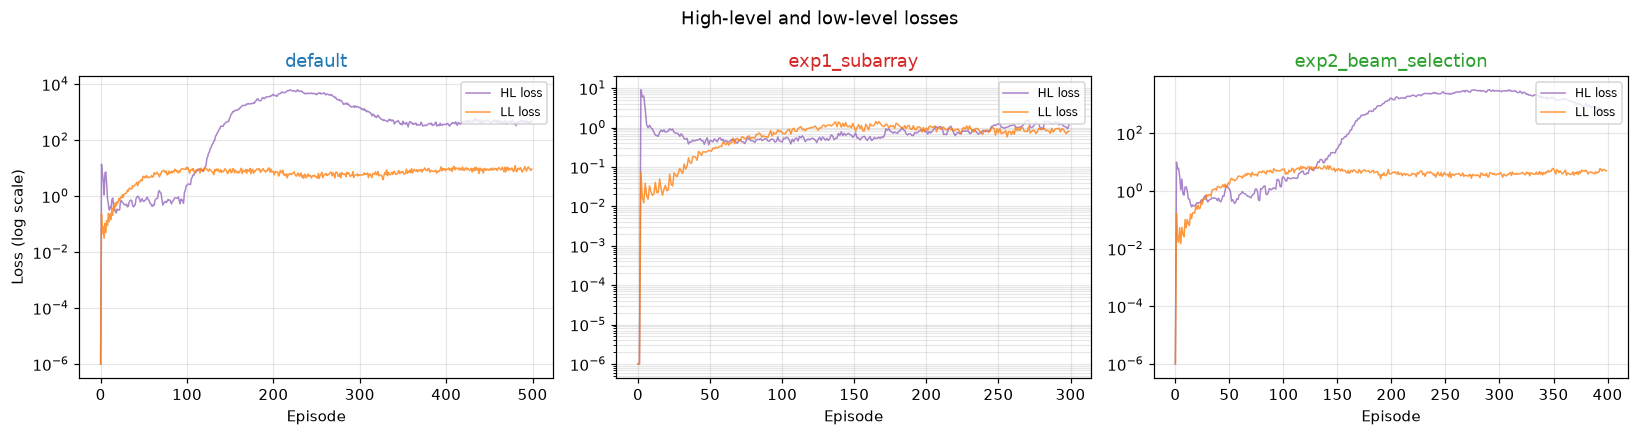

<Figure size 704x528 with 0 Axes>

In [6]:
# %% Cell 6: FIGURE 4 - Losses (subplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, EXPERIMENTS):
    df = dfs[name]
    eps = df["episode"].values
    hl = df["high_level_loss"].values
    ll = df["low_level_loss"].values
    # Use log scale for stability
    ax.semilogy(eps, np.maximum(hl, 1e-6), color="tab:purple",
                linewidth=1.0, alpha=0.8, label="HL loss")
    ax.semilogy(eps, np.maximum(ll, 1e-6), color="tab:orange",
                linewidth=1.0, alpha=0.8, label="LL loss")
    ax.set_xlabel("Episode")
    ax.set_title(name, color=COLORS[name])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, which="both")

axes[0].set_ylabel("Loss (log scale)")
plt.suptitle("High-level and low-level losses", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_04_losses.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)

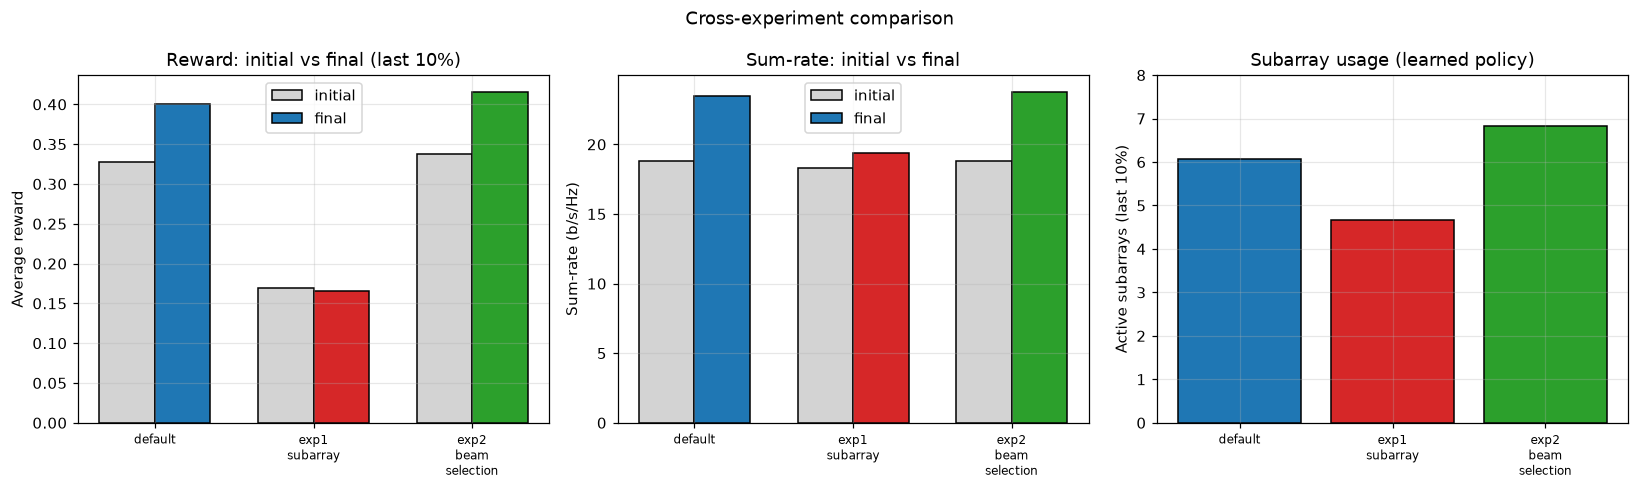

<Figure size 704x528 with 0 Axes>

In [7]:
# %% Cell 7: FIGURE 5 - Comparison bars
summary = {}
for name in EXPERIMENTS:
    df = dfs[name]
    n = len(df)
    k = max(1, n // 10)
    head = df.iloc[:k]
    tail = df.iloc[-k:]
    summary[name] = {
        "init_reward": head["avg_reward"].mean(),
        "final_reward": tail["avg_reward"].mean(),
        "init_rate": head["sum_rate"].mean(),
        "final_rate": tail["sum_rate"].mean(),
        "final_subs": tail["num_active_subarrays"].mean(),
        "episodes": n,
    }

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
names = EXPERIMENTS
xs = np.arange(len(names))
bar_w = 0.35

# Rewards
ax = axes[0]
ax.bar(xs - bar_w/2, [summary[n]["init_reward"] for n in names],
       bar_w, label="initial", color="lightgray", edgecolor="black")
ax.bar(xs + bar_w/2, [summary[n]["final_reward"] for n in names],
       bar_w, label="final", color=[COLORS[n] for n in names],
       edgecolor="black")
ax.set_xticks(xs)
ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8)
ax.set_ylabel("Average reward")
ax.set_title("Reward: initial vs final (last 10%)")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Rates
ax = axes[1]
ax.bar(xs - bar_w/2, [summary[n]["init_rate"] for n in names],
       bar_w, label="initial", color="lightgray", edgecolor="black")
ax.bar(xs + bar_w/2, [summary[n]["final_rate"] for n in names],
       bar_w, label="final", color=[COLORS[n] for n in names],
       edgecolor="black")
ax.set_xticks(xs)
ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8)
ax.set_ylabel("Sum-rate (b/s/Hz)")
ax.set_title("Sum-rate: initial vs final")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# Final subarrays
ax = axes[2]
ax.bar(xs, [summary[n]["final_subs"] for n in names],
       color=[COLORS[n] for n in names], edgecolor="black")
ax.set_xticks(xs)
ax.set_xticklabels([n.replace("_", "\n") for n in names], fontsize=8)
ax.set_ylabel("Active subarrays (last 10%)")
ax.set_title("Subarray usage (learned policy)")
ax.set_ylim(0, 8)
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Cross-experiment comparison", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_05_comparison_bar.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)

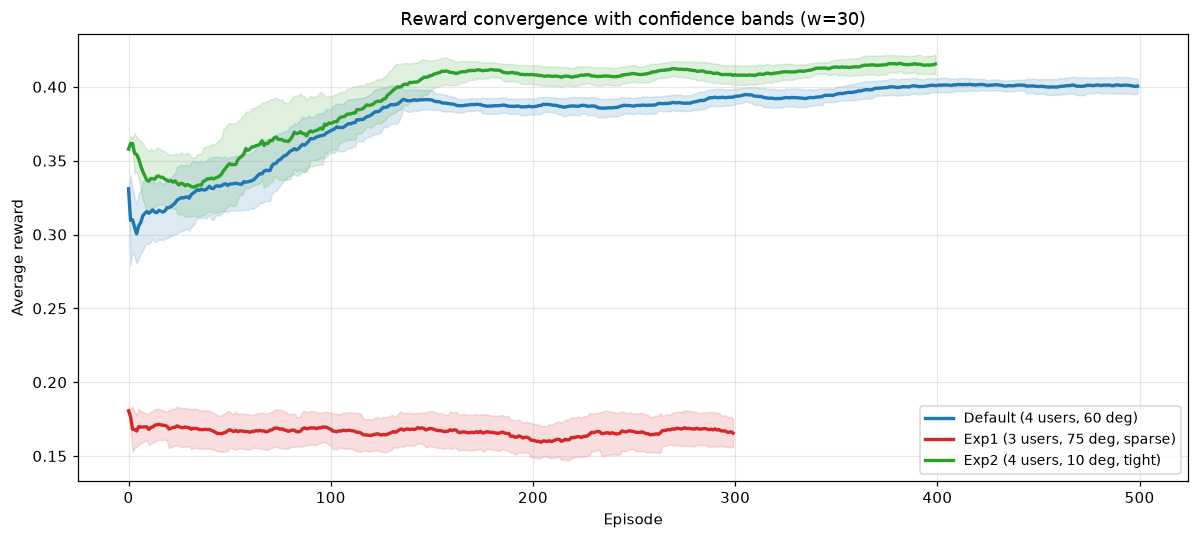

<Figure size 704x528 with 0 Axes>

In [8]:
# %% Cell 8: FIGURE 6 - Convergence bands
fig, ax = plt.subplots(figsize=(11, 5))

WIN = 30

for name in EXPERIMENTS:
    df = dfs[name]
    eps = np.asarray(df["episode"].values, dtype=float)
    reward = np.asarray(df["avg_reward"].values, dtype=float)

    # Rolling mean and std -> force numpy arrays to satisfy Pylance
    s = pd.Series(reward)
    mean = np.asarray(
        s.rolling(WIN, min_periods=1).mean(), dtype=float
    )
    std = np.asarray(
        s.rolling(WIN, min_periods=1).std().fillna(0), dtype=float
    )

    # Explicit float arrays for the band edges
    lower = mean - std
    upper = mean + std

    ax.plot(eps, mean, color=COLORS[name], linewidth=2.2,
            label=LABELS[name])
    ax.fill_between(eps, lower, upper,
                    color=COLORS[name], alpha=0.15)

ax.set_xlabel("Episode")
ax.set_ylabel("Average reward")
ax.set_title(f"Reward convergence with confidence bands (w={WIN})")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_06_convergence.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)

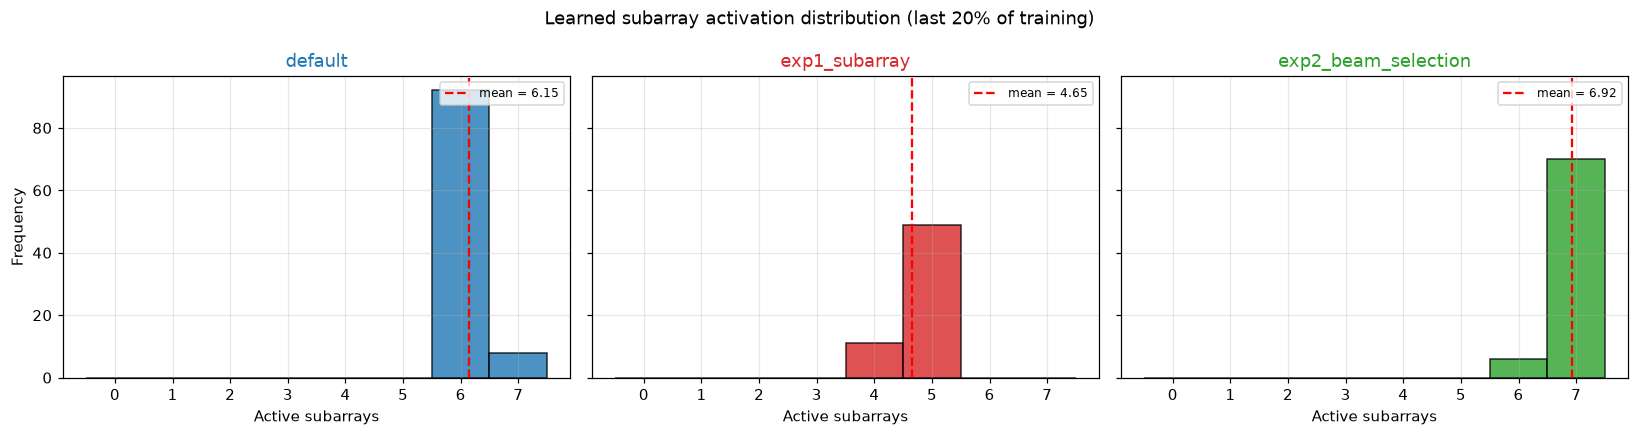

<Figure size 704x528 with 0 Axes>

In [9]:
# %% Cell 9: FIGURE 7 - Subarray histogram (subplots)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, EXPERIMENTS):
    df = dfs[name]
    # Use last 20% (learned policy, low epsilon)
    n = len(df)
    tail = df.iloc[-max(20, n // 5):]
    subs = tail["num_active_subarrays"].values

    bins = np.arange(0, 9) - 0.5
    ax.hist(subs, bins=bins, color=COLORS[name], edgecolor="black",
            alpha=0.8)
    mean_subs = float(np.mean(subs))
    ax.axvline(mean_subs, color="red", linestyle="--",
               label=f"mean = {mean_subs:.2f}")
    ax.set_xlabel("Active subarrays")
    ax.set_title(name, color=COLORS[name])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")

axes[0].set_ylabel("Frequency")
plt.suptitle("Learned subarray activation distribution (last 20% of training)",
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_07_subarray_hist.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)

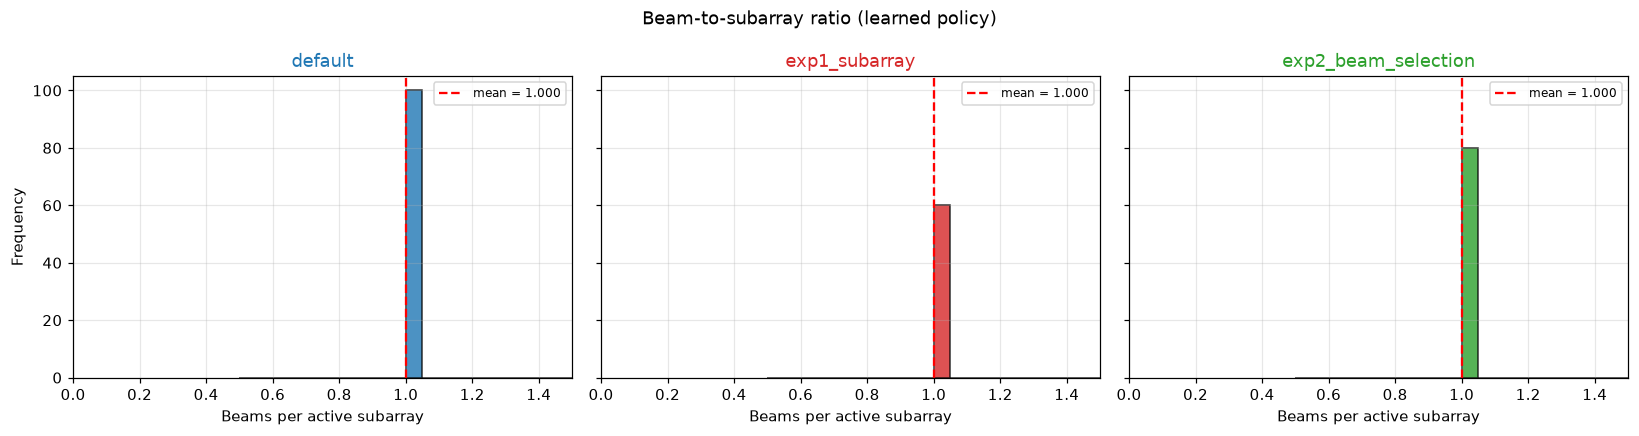

<Figure size 704x528 with 0 Axes>

In [10]:
# %% Cell 10: FIGURE 8 - Beam distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, EXPERIMENTS):
    df = dfs[name]
    n = len(df)
    tail = df.iloc[-max(20, n // 5):]
    beams = tail["num_active_beams"].values
    subs = tail["num_active_subarrays"].values

    # Beams per active subarray = beams / subs (safe division)
    ratio = np.divide(beams, subs, out=np.ones_like(beams), where=subs > 0)

    ax.hist(ratio, bins=20, color=COLORS[name], edgecolor="black", alpha=0.8)
    ax.axvline(np.mean(ratio), color="red", linestyle="--",
               label=f"mean = {np.mean(ratio):.3f}")
    ax.set_xlabel("Beams per active subarray")
    ax.set_title(name, color=COLORS[name])
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3, axis="y")
    ax.set_xlim(0, 1.5)

axes[0].set_ylabel("Frequency")
plt.suptitle("Beam-to-subarray ratio (learned policy)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_08_beam_distribution.png"))
plt.show()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "analysis_XX_....png"))
plt.show()
plt.close(fig)

In [11]:
# %% Cell 11: Results table + CSV export
print("=" * 78)
print("Results summary (last 10% of training)")
print("=" * 78)

rows = []
for name in EXPERIMENTS:
    df = dfs[name]
    n = len(df)
    k = max(1, n // 10)
    head = df.iloc[:k]
    tail = df.iloc[-k:]
    rows.append({
        "Experiment": name,
        "Episodes": n,
        "Reward (init)": round(head["avg_reward"].mean(), 4),
        "Reward (final)": round(tail["avg_reward"].mean(), 4),
        "Reward delta": round(tail["avg_reward"].mean()
                              - head["avg_reward"].mean(), 4),
        "Rate (init)": round(head["sum_rate"].mean(), 3),
        "Rate (final)": round(tail["sum_rate"].mean(), 3),
        "Rate delta": round(tail["sum_rate"].mean()
                            - head["sum_rate"].mean(), 3),
        "Final subarrays": round(tail["num_active_subarrays"].mean(), 2),
    })

results_df = pd.DataFrame(rows)
print("\n" + results_df.to_string(index=False))

# Save to CSV
csv_out = os.path.join(RUNS_DIR, "comparison_table.csv")
results_df.to_csv(csv_out, index=False)
print(f"\nSaved: {csv_out}")

# Also save as a markdown table
md_out = os.path.join(RUNS_DIR, "comparison_table.md")
with open(md_out, "w", encoding="utf-8") as f:
    f.write("# Cross-Experiment Results\n\n")
    f.write(results_df.to_markdown(index=False))
    f.write("\n")
print(f"Saved: {md_out}")

print("\n" + "=" * 78)
print("Training analysis complete. 8 figures generated.")
print("=" * 78)

Results summary (last 10% of training)

         Experiment  Episodes  Reward (init)  Reward (final)  Reward delta  Rate (init)  Rate (final)  Rate delta  Final subarrays
            default       500         0.3271          0.4006        0.0735       18.784        23.447       4.664             6.07
      exp1_subarray       300         0.1693          0.1655       -0.0038       18.321        19.357       1.037             4.66
exp2_beam_selection       400         0.3376          0.4160        0.0784       18.777        23.790       5.013             6.83

Saved: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\runs\comparison_table.csv
Saved: c:\Users\ROG007\Documents\year 2\tri sem 4\ml\project\hdrl_mimo_sys\runs\comparison_table.md

Training analysis complete. 8 figures generated.
